In [ ]:
import numpy as np
# from scipy.linalg import cho_factor, cho_solve
from scipy.special import logsumexp
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
np.random.seed(122)

In [ ]:
# params
n = 50    # data sample
M = 1000  # posterior sample
p = 2     # dim of X (polynomial)
H = 6     # num of (treatment) assignments
b0 = np.array([1.0, 1.0, 0.5])  # true coeffs

# prior: beta ~ N(0, sigma^2 * S^-1)

S = 0.001 * np.eye(p + 1) 


In [ ]:
# helper fns

# polynomial feature vector
def polygen(h, p):
    return np.array([h**i for i in range(p + 1)], dtype=float)

# generate X
# row h = polynomial features of h (starting at 1)
def Xgen(H, p):
    return np.array([polygen(h, p) for h in range(1, H + 1)])  # shape (H, p+1)

# softmax propensity score
def propensityscore(z_val, alpha):
    vals = np.exp(alpha * z_val)
    return vals / vals.sum()

# Unweighted log-likelihood for all posterior draws
def log_h_test_vec(theta_mat, y, x):
    beta = theta_mat[:, :-1]          # (M, p+1)
    tau  = theta_mat[:, -1]           # (M,)
    res  = y - beta @ x               # (M,)
    return (-tau / 2) * res**2 - 0.5 * np.log(2 * np.pi / tau)  # (M,)

# Log Likelihood for the training
def log_s_train_vec(theta_mat, y, x, w):
    return w * log_h_test_vec(theta_mat, y, x)

In [43]:
# generate data
X_nonortho = Xgen(H, p)                              # shape (H, p+1)
Z          = np.random.uniform(-np.sqrt(3), np.sqrt(3), size=n)   # confounder
epsilon    = np.random.normal(0, 1, size=n)           # independent noise
varepsilon = Z + epsilon                              # composite noise in Y

# Potential outcomes: Ys[h, i] = X_nonortho[h,:] @ b0 + varepsilon[i]
# Equivalent to R: c(X_nonortho%*%b0) %o% rep(1,n) + c(1,...,1) %o% varepsilon
Ys = np.outer(X_nonortho @ b0, np.ones(n)) + np.outer(np.ones(H), varepsilon)  # (H, n)

alpha = np.array([0.0, 0.8, 1.0, 0.9, 0.7, 0.6])    # propensity score params

# Propensity scores: eis[h, i] = P(T=h | Z=Z[i])
eis = np.column_stack([propensityscore(z_val, alpha) for z_val in Z])  # (H, n)

# Treatment assignments: Tis[h, i] = 1{T_i = h}
Tis = np.column_stack([
    np.random.multinomial(1, eis[:, i]) for i in range(n)
])  # (H, n)

# Inverse probability weights
Wis = Tis / eis   # (H, n)

In [44]:
# Orthogonalise X via Cholesky
# unsure why we are doing this..? seems to just be a mathematical convenience from the original paper
Xblock_pre = X_nonortho.T @ X_nonortho          # (p+1, p+1),
A = np.linalg.cholesky(Xblock_pre).T            # upper-triangular
X = X_nonortho @ np.linalg.pinv(A)              # orthogonalised, shape (H, p+1)

# each chunk of n rows (block) corresponds to one treatment, with n rows

# Ys is (H, n)
# Yblock: (n*H,)
Yblock = Ys.flatten()

# Wblock: block-diagonal (n*H, n*H), block h = diag(Wis[h, :])
Wblock = np.zeros((n * H, n * H))
for h in range(H):
    Wblock[h*n:(h+1)*n, h*n:(h+1)*n] = np.diag(Wis[h, :])

# Xblock: (n*H, p+1) — repeat row X[h,:] n times for block h
Xblock = np.zeros((n * H, p + 1))
for h in range(H):
    Xblock[h*n:(h+1)*n, :] = np.tile(X[h, :], (n, 1))

In [ ]:
# Posterior distribution
# beta | data ~ N(mu_pos,  sigma^2 * Sigma_pos)
# tau = 1/sigma^2 -- fixed at true value
XtWX      = Xblock.T @ Wblock @ Xblock          # (p+1, p+1)
Sigma_pos = np.linalg.pinv(XtWX + S)            # posterior covariance scale
mu_pos    = Sigma_pos @ (Xblock.T @ Wblock @ Yblock)   # posterior mean

sigma2_true = float(np.var(varepsilon))          # true noise variance
tau_true    = 1.0 / sigma2_true

# Draw M posterior samples
possample_beta  = multivariate_normal.rvs(
    mean=mu_pos, cov=sigma2_true * Sigma_pos, size=M
)                                                # (M, p+1)
possample_tau   = np.full(M, tau_true)           # (M,)
possample_theta = np.column_stack([possample_beta, possample_tau])  # (M, p+2)

# Observed data (what is actually measured for each individual)
Y_obs = np.sum(Tis * Ys, axis=0)   # (n,) observed outcome
X_obs = Tis.T @ X                  # (n, p+1) observed covariates


In [ ]:
# Compute WPCIC / UPCIC
# Tn for weighted kernel
T_n_seq  = np.zeros(n)
# Tn for unweighted kernel
UT_n_seq = np.zeros(n)
# Vn for weighted kernel
V_n_seq  = np.zeros(n)
# Vn for unweighted kernel
UV_n_seq = np.zeros(n)

for N in range(n):
    y_N   = Y_obs[N]
    x_N   = X_obs[N, :]
    w_N   = float(np.sum(Wis[:, N]))   # sum of weights for individual N

    # log p(y_N | theta^(m))
    ll = log_h_test_vec(possample_theta, y_N, x_N)   # (M,)

    # T_n: weighted/unweighted negative log predictive density
    # = -log[ (1/M) sum_m p(y|theta^(m)) ] * weight
    lppd = logsumexp(ll) + np.log(1.0 / M)           # log mean predictive dens
    T_n_seq[N]  = w_N * (-lppd)
    UT_n_seq[N] = 1.0 * (-lppd)

    # V_n: posterior variance of weighted log-likelihood (penalty term)
    wll = log_s_train_vec(possample_theta, y_N, x_N, w=w_N)   # (M,)
    V_n_seq[N]  = np.mean(wll**2) - np.mean(wll)**2

    uwll = log_s_train_vec(possample_theta, y_N, x_N, w=1.0)  # (M,)
    UV_n_seq[N] = w_N * (np.mean(uwll**2) - np.mean(uwll)**2)

WPCIC = T_n_seq + V_n_seq    # weighted PCIC
UPCIC = UT_n_seq + UV_n_seq  # unweighted PCIC

In [ ]:
def dimi_WCP(y, x, w, ipw):
    # penalty term for WCp
    return (w**2) * float(x @ x) * (y - x @ ipw)**2 

# IPW estimator
mu_IPW = np.linalg.pinv(XtWX) @ (Xblock.T @ Wblock @ Yblock)

WCPi      = np.zeros(n)
UCPi      = np.zeros(n)
pen_UCPi  = np.zeros(n)
body_UCPi = np.zeros(n)
pen_WCPi  = np.zeros(n)
body_WCPi = np.zeros(n)

for N in range(n):
    w_N   = float(np.sum(Wis[:, N]))
    resid = float(Y_obs[N] - X_obs[N, :] @ mu_IPW)

    body_UCPi[N] = (1.0 / (2 * sigma2_true)) * resid**2 + 0.5 * np.log(2 * sigma2_true * np.pi)
    pen_UCPi[N]  = (p + 1) / n

    body_WCPi[N] = (1.0 / (2 * sigma2_true)) * resid**2 * w_N + (w_N / 2) * np.log(2 * sigma2_true * np.pi)
    pen_WCPi[N]  = dimi_WCP(y=Y_obs[N], x=X_obs[N, :], w=w_N, ipw=mu_IPW) / (sigma2_true * n)

    WCPi[N] = body_WCPi[N] + pen_WCPi[N]
    UCPi[N] = body_UCPi[N] + pen_UCPi[N]

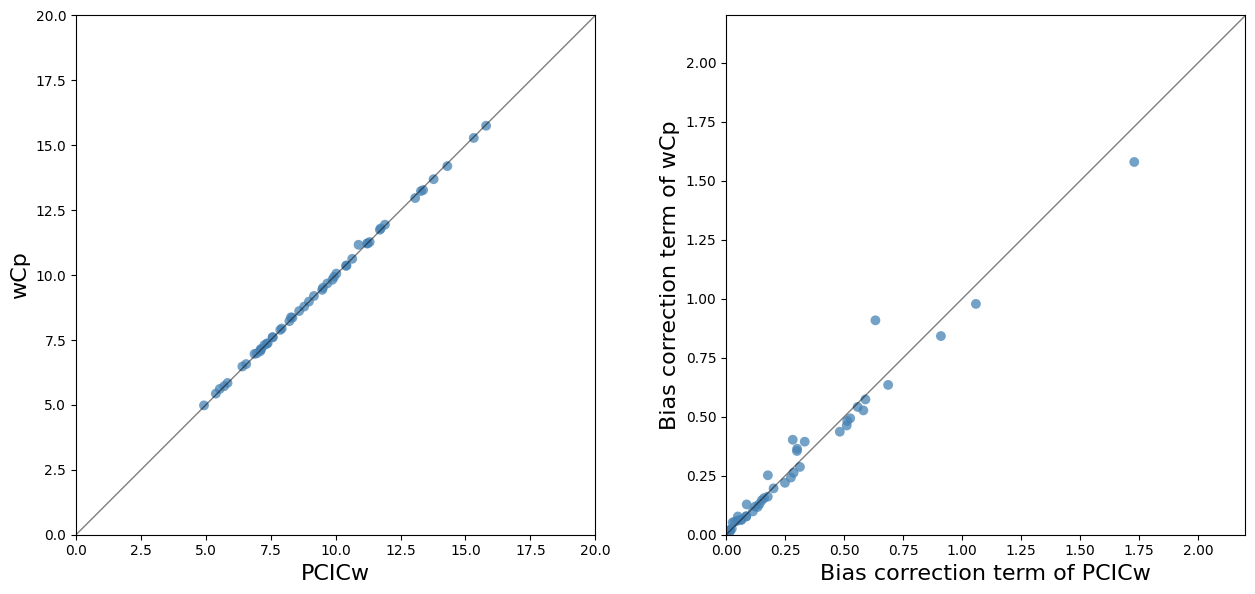

Saved plot to pcic_vs_cp.png


: 

In [ ]:
# plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

# WPCIC vs WCPi
ax1.scatter(WCPi, WPCIC, alpha=0.75, color="steelblue", edgecolors="none", s=50)
ax1.set_xlim(0, 20)
ax1.set_ylim(0, 20)
ax1.set_xlabel("PCICw", fontsize=16)
ax1.set_ylabel("wCp",   fontsize=16)
ax1.plot([0, 20], [0, 20], color="black", alpha=0.5, linewidth=1)
ax1.set_aspect("equal")

# Plot 2: V_n_seq (PCIC penalty) vs pen_WCPi (Cp penalty)
ax2.scatter(pen_WCPi, V_n_seq, alpha=0.75, color="steelblue", edgecolors="none", s=50)
ax2.set_xlim(0, 2.2);  ax2.set_ylim(0, 2.2)
ax2.set_xlabel("Bias correction term of PCICw", fontsize=16)
ax2.set_ylabel("Bias correction term of wCp",   fontsize=16)
ax2.plot([0, 2.2], [0, 2.2], color="black", alpha=0.5, linewidth=1)
ax2.set_aspect("equal") 

plt.tight_layout()
plt.show()
print("Saved plot to pcic_vs_cp.png")

notes:
n --> number of i.i.d. observations
M --> number of posterior samples used to approximate posterior expectations
p --> degree of polynomial
H --> number of treatments in the marginal structural model
IPW --> inverse-probability-weighted estimation
epsilon --> independent error term with mean zero and variance sigma^2
Tis --> treatment indicator: Tis[h,i] = 1 if individual i received treatment h
Ys --> potential outcomes for all individuals i and all treatments h
Y_obs --> observed outcome for each individual (only one treatment realised per individual)
X_obs --> observed covariates for each individual under their realised treatment
tau --> 1/sigma^2

X --> orthogonalised design matrix (polynomial features of treatment levels)
X_nonortho --> raw polynomial features [1, h, h^2] for each treatment h
varepsilon --> composite error term including confounder Z and pure noise epsilon
eis --> propensity scores: P(t[h,i] = 1 | z_i)
alpha --> parameters controlling how strongly Z biases treatment assignment
Xblock_pre --> from before orthogonalization
Xblock --> design matrix stacked across all H treatment blocks (nH x (p+1))
Yblock --> outcomes stacked across all H treatment blocks (nH,)
XtWX --> IPW-weighted information matrix; captures how much the data inform beta

Sigma_pos --> posterior covariance of beta (how uncertain we are after seeing data)
mu_pos --> posterior mean of beta (best estimate after seeing data)
sigma2_true --> true noise variance, known because this is a simulation
tau_true --> 1/sigma2_true, fixed constant in this simulation

possample_beta --> M draws of beta from the posterior distribution
possample_tau --> M copies of tau_true (fixed, not sampled)
possample_theta --> M posterior draws of the full parameter vector (beta, tau)

w_i --> t/e
ll --> log-likelihood of individual i's outcome under each posterior draw
lppd --> log quasi-Bayesian predictive density for individual i
T_n_seq --> goodness-of-fit term of WPCIC = -w_i * log E_posterior[h_i(Y_i | theta)]
UT_n_seq --> goodness-of-fit term of UPCIC: same with w_i = 1
V_n_seq --> penalty term of WPCIC = Cov_posterior[log h_i(Y_i | theta), s_i(Y_i, theta)]
UV_n_seq --> penalty term of UPCIC: same with unweighted score s_i

mu_IPW --> inverse-probability-weighted estimator of beta (no prior, frequentist version)
resid --> Y_obs[i] - X_obs[i] @ mu_IPW

body_UCPi --> unweighted goodness-of-fit term for individual i
pen_UCPi --> (p+1)/n, same for every individual
body_WCPi --> weighted goodness-of-fit term for individual i
pen_WCPi --> w_i^2 * leverage term / (sigma^2 * n)
WCPi --> body_WCPi + pen_WCPi
UCPi --> body_UCPi + pen_UCPi